# Statistics Final Exam: 
## Statistical Analysis of the Bullet Cluster
#### Renzo
#### Roberto
#### Thiele
#### Juan David Galan Vargas

### Libraries and Models

In [2]:
import numpy as np
import matplotlib . pyplot as plt
from scipy.optimize import minimize , curve_fit
from scipy.stats import chi2 as chi2dist , norm as normdist
from scipy.stats import t as tdist , f as fdist , kstest
from scipy.integrate import quad
import pandas as pd
import warnings
warnings.filterwarnings ("ignore")


In [3]:
# PROVIDED MODELS ---

def model_2gauss(x , A1 , mu1 , sig1 , A2 , mu2 , sig2 ):
    #" " " Two - component Gaussian profile . " " "
    return ( A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) ) + A2 * np . exp ( -(x - mu2 ) **2/(2* sig2 **2) ) )
def model_1gauss (x , A1 , mu1 , sig1 ) :
#" " " Single - component Gaussian profile . " " "
    return A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) )

def model_2beta (x , S1 , x1 , r1 , b1 , S2 , x2, r2, b2):
#" " " Two - component beta profile . " " "
    return ( S1 /(1+(( x - x1 ) / r1 ) **2) ** b1 + S2 /(1+(( x - x2 ) / r2 ) **2) ** b2 )
def model_1beta (x , S1 , x1 , r1 , b1 ) :
#" " " Single - component beta profile . " " "
    return S1 /(1+(( x - x1 ) / r1 ) **2) ** b1
#
# PHYSICAL CONSTANTS --- PROVIDED
#
arcmin_to_Mpc = 0.157 # 1 arcmin at z =0.296
M_per_gal= 2e11 # Msun per galaxy
M_per_SX= 1.5e10# Msun per X - ray count
M_per_kappa = 3e14# Msun per unit integrated kappa

### Part 0: Data

In [4]:
data=pd.read_csv("BulletClusterData.csv") #"z"

### Part 1: Redshift Distribution and Cluster Membership

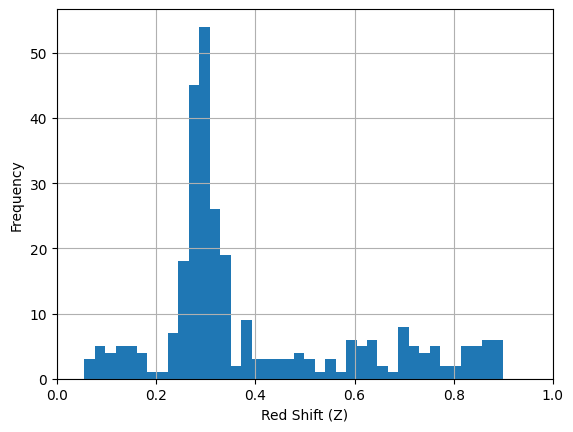

In [6]:
# TODO 1.1 Plot the redshift histogram of z all using 40 bins over [0, 1].
# Identify the cluster peak visually. Label axes and add a title.
n, bins, patches = plt.hist(data["z"],bins=40)
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.show()


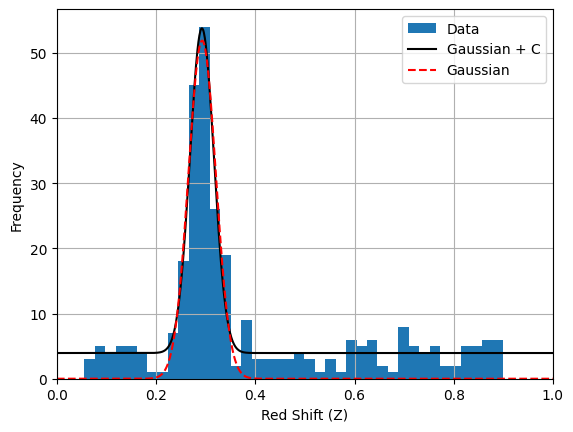

Gauss + C: Parameter: Z_cl: 0.292360011589899 . Standar Deviation Error: 0.001221688613203904
Gauss + C: Parameter: Sigma_cl: 0.024057043815003728 . Standar Deviation Error: 0.0012576056749231193
Gauss: Parameter: Z_cl: 0.2927960627711147 . Standar Deviation Error: 0.0022238739994477285
Gauss: Parameter: Sigma_cl: 0.02762430242534291 . Standar Deviation Error: 0.0022238717550833427


In [17]:
#Fit a Gaussian+background model to the cluster peak using MLE:
bins_center = 0.5*(bins[:-1] + bins[1:])

def gaussian_plus_background(z,A,z_cl,sigma_cl,C):
    return A* np.exp((-1*(z-z_cl)**2)/(2* sigma_cl**2)) + C


x= np.linspace(0,1,1000)

popt_bc, pcov_bc = curve_fit(gaussian_plus_background,bins_center,n)
popt_nobc, pcov_nobc = curve_fit(model_1gauss,bins_center,n)

plt.hist(data["z"],bins=40, label="Data")
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,gaussian_plus_background(x, *popt_bc),label="Gaussian + C",color="black")
plt.plot(x,model_1gauss(x,*popt_nobc),label="Gaussian",color="red",ls="--")
plt.legend()
plt.show()
perr_bc = np.sqrt(np.diag(pcov_bc))
perr_nobc = np.sqrt(np.diag(pcov_nobc))

print("Gauss + C: Parameter: Z_cl: "+str(popt_bc[1])+" . Standar Deviation Error: "+str(perr_bc[1]))
print("Gauss + C: Parameter: Sigma_cl: "+str(popt_bc[2])+" . Standar Deviation Error: "+str(perr_bc[2]))
z_bc=popt_bc[1]
sigma_bc=popt_bc[2]
z_nobc=popt_nobc[1]
sigma_nobc=popt_nobc[2]
print("Gauss: Parameter: Z_cl: "+str(popt_nobc[1])+" . Standar Deviation Error: "+str(perr_nobc[1]))
print("Gauss: Parameter: Sigma_cl: "+str(popt_nobc[2])+" . Standar Deviation Error: "+str(perr_nobc[2]))


In [20]:
#Define cluster membership: a galaxy belongs to the cluster if |z − ẑcl| < 3σ̂cl.
#Count how many galaxies satisfy this criterion. Report the fraction of members vs. total.
sigmas=[3,2,1]

for i in sigmas:
    member_counter=0
    for j in data["z"]:
    #print(i)
        if np.abs(j - z_bc) < i*sigma_bc:
            member_counter+=1
    fracc=member_counter/len(data["z"])
    print("fraction of galaxies that belong to the cluster: "+str(fracc)+" for sigmas: "+str(i))

fraction of galaxies that belong to the cluster: 0.57 for sigmas: 3
fraction of galaxies that belong to the cluster: 0.5333333333333333 for sigmas: 2
fraction of galaxies that belong to the cluster: 0.35 for sigmas: 1


In [8]:
#Compute χ̃2 for the Gaussian+background fit. Is the fit acceptable?
# Compare with a single Gaussian (no C) and comment on the difference. (model1_gauss)

def chi2_val(model,num_params):
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    y_fit = model#gaussian_plus_background(centers, *popt)
    chi2 = float(np.sum(((n - y_fit)/sigma)**2))
    dof = len(n) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red

popt, pcov = curve_fit(gaussian_plus_background,bins_center,n)
print("Curve fit: Gaussian + Background")
print(chi2_val(gaussian_plus_background(n,*popt),popt))
popt, pcov = curve_fit(model_1gauss,bins_center,n)
print("Curve fit: Gaussian")
print(chi2_val(model_1gauss(n,*popt),popt))

guess = [
    n.max(),                     # amplitude
    bins_center[np.argmax(n)],       # mean
    np.std(data["z"]),                # sigma
    n.min()                      # background
]

def chi2(params):
    model = gaussian_plus_background(bins_center, *params)
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    return np.sum(((n - model) / sigma)**2)

result = minimize(chi2, guess)

best_params = result.x
print("Minimize Chi Square: Gaussian + Background")
print(chi2_val(gaussian_plus_background(n,*best_params),best_params))

def chi2_nobc(params):
    model = model_1gauss(bins_center, *params)
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    return np.sum(((n - model) / sigma)**2)

guess.pop()
result = minimize(chi2_nobc, guess)

best_params = result.x
print("Minimize Chi Square: Gaussian")
print(chi2_val(model_1gauss(n,*best_params),best_params))

del popt, pcov, guess, result, best_params, sigmas, x 



Curve fit: Gaussian + Background
5.257361851175897
Curve fit: Gaussian
8.108108108108109
Minimize Chi Square: Gaussian + Background
4.961972455516931
Minimize Chi Square: Gaussian
8.108108108108109


### Part 2: Profile Fitting

#### Galaxy Number Density

In [ ]:
#Variable renaming
x_bins=bins_center
N_obs= n
sigma_N = np.sqrt(n)
sigma_N[sigma_N == 0] = 1.0

del bins_center, n


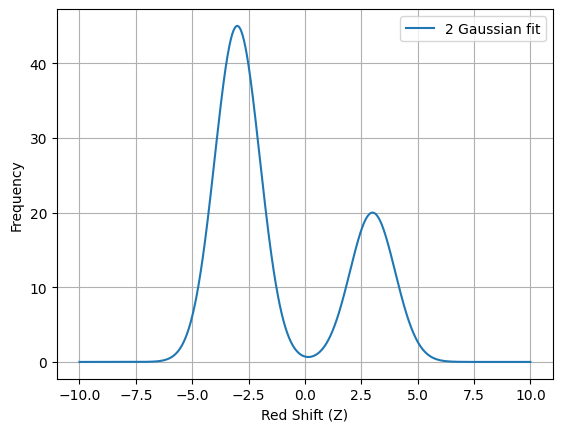

Parameter: Z_cl: 0.29279596512328965 . Standar Deviation Error: 0.001221688613203904
Parameter: Sigma_cl: 0.027624061335812525 . Standar Deviation Error: 0.0012576056749231193


In [18]:
#Fit model 2gauss to N obs using curve fit
# Initial guess: A1 ≈ 45, µ1 ≈ −3, σ1 ≈ 1, A2 ≈ 20, µ2 ≈ 3, σ2 ≈ 1
# Store popt N, pcov N.
#x , A1 , mu1 , sig1 , A2 , mu2 , sig2
initial_guess=[45,-3,1,20,3,1]
x= np.linspace(-10,10,1000)
#popt_N, pcov_N = curve_fit(model_2gauss,x_bins,N_obs,p0=initial_guess)
#plt.hist(data["z"],bins=40, label="Data")
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
#plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_2gauss(x, *initial_guess),label="2 Gaussian fit")
plt.legend()
plt.show()
perr_N = np.sqrt(np.diag(pcov_N))
print("Parameter: Z_cl: "+str(popt_N[1])+" . Standar Deviation Error: "+str(perr[1]))
print("Parameter: Sigma_cl: "+str(popt_N[2])+" . Standar Deviation Error: "+str(perr[2]))
z_cl_N=popt_N[1]
sigma_cl_N=popt_N[2]
